In [1]:
# uv 프로젝트 환경이 있으면 uv sync로 의존성 설치 (권장)
!pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pingouin scikit_posthocs xgboost -q
print("pip 설치 완료!")

pip 설치 완료!


In [2]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [4]:
df_origin = pd.read_csv('2019-Oct.csv')
df = df_origin.copy()

In [5]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [6]:
df['category_code'].value_counts()

category_code
electronics.smartphone          11507231
electronics.clocks               1311033
computers.notebook               1137623
electronics.video.tv             1113750
electronics.audio.headphone      1100188
                                  ...   
apparel.shorts                       632
construction.tools.soldering         632
apparel.jacket                       436
auto.accessories.anti_freeze         308
country_yard.furniture.bench         190
Name: count, Length: 126, dtype: int64

In [7]:
df[df['category_code'] == 'electronics.smartphone']['brand'].value_counts()

brand
samsung       3778167
apple         3272845
xiaomi        2200549
huawei        1001883
oppo           482887
meizu          155562
vivo           113205
honor           76915
nokia           70639
sony            67481
oneplus         65871
lg              24125
tp-link         22664
bq              20797
doogee          18177
inoi            16575
google          15436
prestigio       14298
haier           11053
zte             10762
asus             6617
tecno            5933
jinga            4472
gionee           4038
umi              3724
blackberry       3686
irbis            3483
htc              3312
fly              2922
nubia            2099
texet            1291
leeco            1046
vertex            916
micromax          673
philips           625
oukitel           235
leagoo            207
hiper              67
ark                60
motorola           23
bravis              1
Name: count, dtype: int64

In [8]:
df[df['category_code'] == 'electronics.smartphone']['brand'].value_counts(normalize=True) * 100

brand
samsung       32.895615
apple         28.495895
xiaomi        19.159665
huawei         8.723161
oppo           4.204384
meizu          1.354442
vivo           0.985649
honor          0.669681
nokia          0.615037
sony           0.587541
oneplus        0.573523
lg             0.210051
tp-link        0.197330
bq             0.181075
doogee         0.158263
inoi           0.144315
google         0.134398
prestigio      0.124489
haier          0.096236
zte            0.093702
asus           0.057613
tecno          0.051657
jinga          0.038937
gionee         0.035158
umi            0.032424
blackberry     0.032093
irbis          0.030326
htc            0.028837
fly            0.025441
nubia          0.018276
texet          0.011240
leeco          0.009107
vertex         0.007975
micromax       0.005860
philips        0.005442
oukitel        0.002046
leagoo         0.001802
hiper          0.000583
ark            0.000522
motorola       0.000200
bravis         0.000009
Name: prop

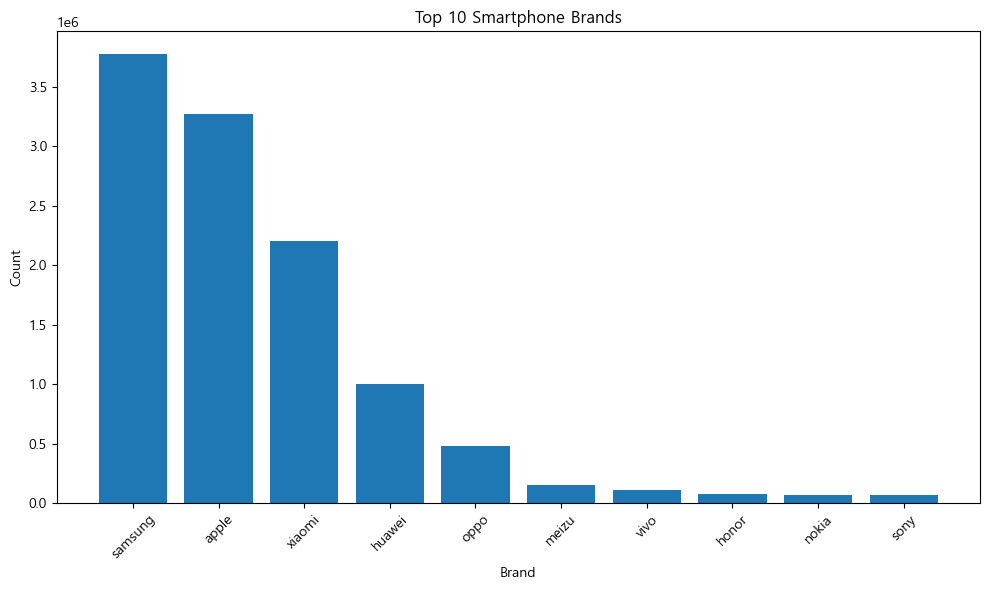

In [9]:
top_brands = df[df['category_code'] == 'electronics.smartphone']['brand'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_brands.index, top_brands.values)
plt.title('Top 10 Smartphone Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
#이벤트 타입 변환

df['event_time'] = pd.to_datetime(df['event_time'], utc=True).dt.tz_convert('Asia/Seoul').dt.tz_localize(None)

In [11]:
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.dayofweek  # 0=월요일, 6=일요일
df['day_name'] = df['event_time'].dt.day_name()

# 구매(purchase) 이벤트만 필터링 (event_type 컬럼이 있다면)
purchases = df[df['event_type'] == 'purchase']

# 시간대별 집계
hourly = purchases.groupby('hour').size().reset_index(name='count')
print(hourly)

    hour  count
0      0  37632
1      1  35773
2      2  30873
3      3  24325
4      4  16748
5      5   9892
6      6   6278
7      7   3837
8      8   2802
9      9   2949
10    10   5526
11    11  13968
12    12  29634
13    13  41146
14    14  48071
15    15  52005
16    16  53406
17    17  55197
18    18  55183
19    19  51904
20    20  47311
21    21  41888
22    22  39138
23    23  37363


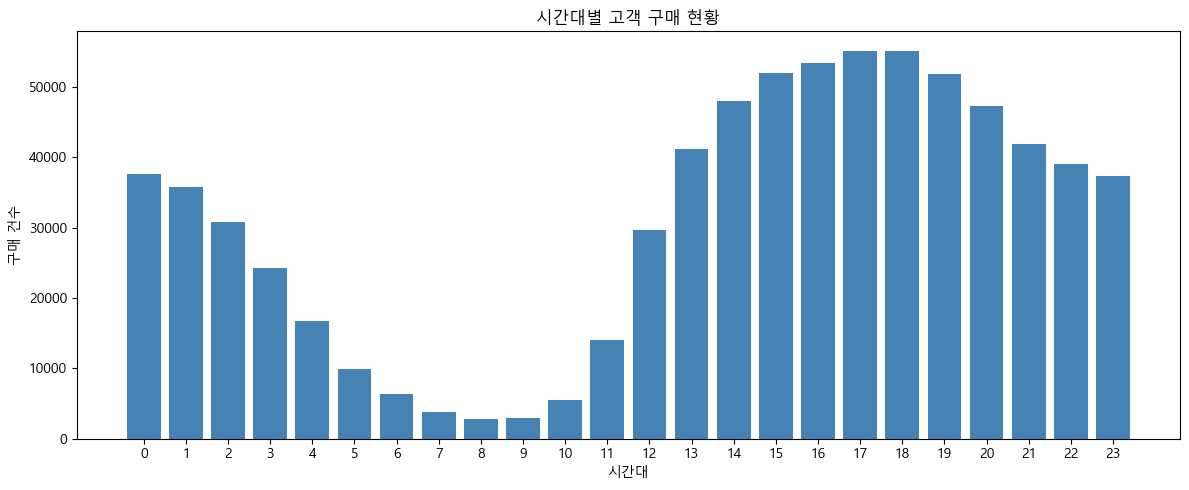

In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시간대별 막대 그래프
plt.figure(figsize=(12, 5))
plt.bar(hourly['hour'], hourly['count'], color='steelblue')
plt.xlabel('시간대')
plt.ylabel('구매 건수')
plt.title('시간대별 고객 구매 현황')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [13]:
def time_segment(hour):
    if 6 <= hour < 12:
        return '오전 (6-12시)'
    elif 12 <= hour < 18:
        return '오후 (12-18시)'
    elif 18 <= hour < 24:
        return '저녁 (18-24시)'
    else:
        return '새벽 (0-6시)'

purchases['time_segment'] = purchases['hour'].apply(time_segment)
print(purchases['time_segment'].value_counts())

time_segment
오후 (12-18시)    279459
저녁 (18-24시)    272787
새벽 (0-6시)      155243
오전 (6-12시)      35360
Name: count, dtype: int64


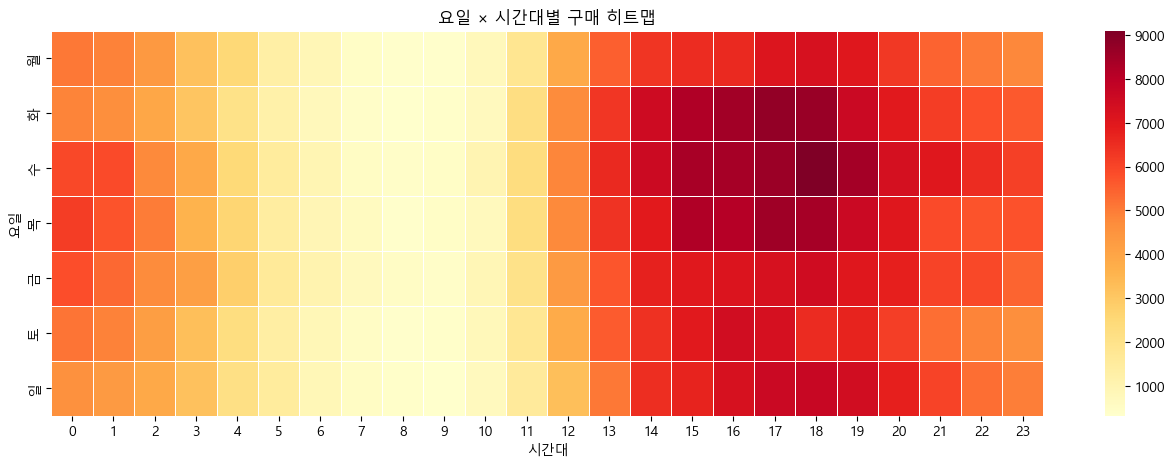

In [14]:
import seaborn as sns

heatmap_data = purchases.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = ['월', '화', '수', '목', '금', '토', '일']

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5)
plt.title('요일 × 시간대별 구매 히트맵')
plt.xlabel('시간대')
plt.ylabel('요일')
plt.show()

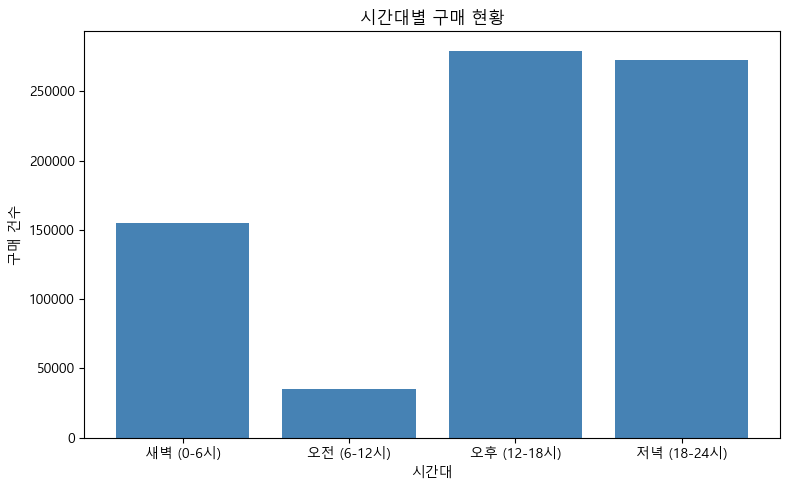

In [15]:

# 구매 이벤트 필터링 & 시간대 구간 추출
purchases = df[df['event_type'] == 'purchase'].copy()
purchases['hour'] = purchases['event_time'].dt.hour
purchases['time_segment'] = purchases['hour'].apply(time_segment)

# 순서 지정
segment_order = ['새벽 (0-6시)', '오전 (6-12시)', '오후 (12-18시)', '저녁 (18-24시)']
segment_counts = purchases['time_segment'].value_counts().reindex(segment_order)

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values, color='steelblue')
plt.xlabel('시간대')
plt.ylabel('구매 건수')
plt.title('시간대별 구매 현황')
plt.tight_layout()
plt.show()

In [ ]:
#구매 전환 소요 시간 계산

# 구매가 있는 세션만 필터링
sessions_with_purchase = df[df['event_type'] == 'purchase']['user_session'].unique()
df_filtered = df[df['user_session'].isin(sessions_with_purchase)]

# 세션별 첫 view 시간
first_view = (
    df_filtered[df_filtered['event_type'] == 'view']
    .groupby('user_session')['event_time']
    .min()
    .rename('first_view_time')
)

# 세션별 첫 purchase 시간
first_purchase = (
    df_filtered[df_filtered['event_type'] == 'purchase']
    .groupby('user_session')['event_time']
    .min()
    .rename('first_purchase_time')
)

# 합치기
conversion = pd.concat([first_view, first_purchase], axis=1).dropna()

# 전환까지 걸린 시간 (분 단위)
conversion['conversion_minutes'] = (
    conversion['first_purchase_time'] - conversion['first_view_time']
).dt.total_seconds() / 60

# view가 purchase보다 늦은 이상한 케이스 제거
conversion = conversion[conversion['conversion_minutes'] >= 0]

print(conversion['conversion_minutes'].describe())

count    627691.000000
mean          6.987661
std          67.140703
min           0.100000
25%           1.383333
50%           2.966667
75%           6.466667
max       28620.350000
Name: conversion_minutes, dtype: float64


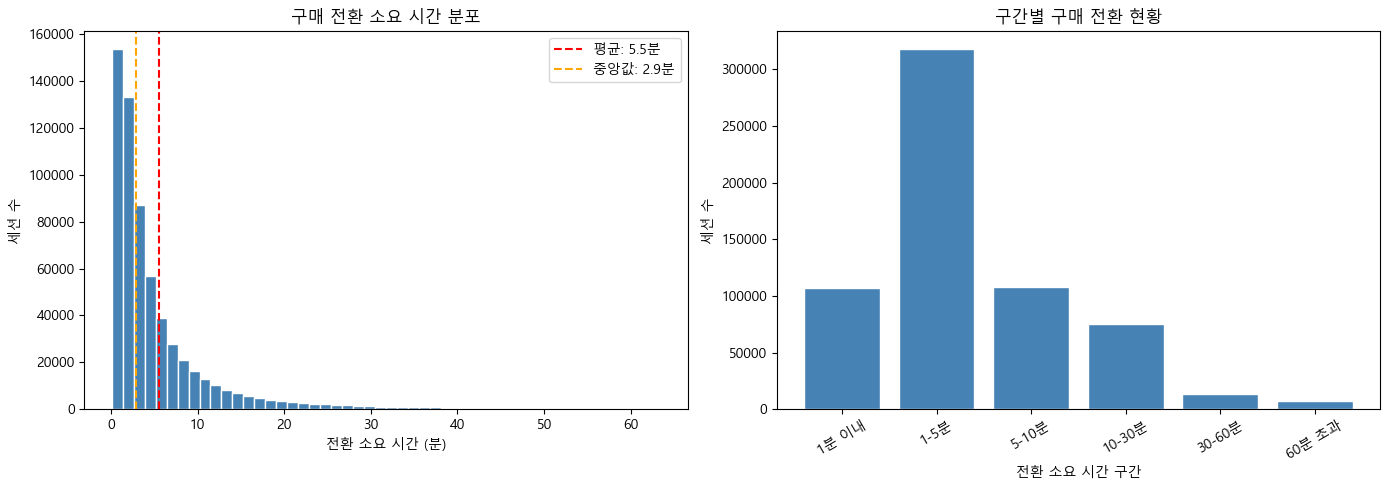

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 이상치 제거 (상위 1%)
upper = conversion['conversion_minutes'].quantile(0.99)
data = conversion[conversion['conversion_minutes'] <= upper]['conversion_minutes']

# 1. 분포 히스토그램
axes[0].hist(data, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(data.mean(), color='red', linestyle='--', label=f'평균: {data.mean():.1f}분')
axes[0].axvline(data.median(), color='orange', linestyle='--', label=f'중앙값: {data.median():.1f}분')
axes[0].set_xlabel('전환 소요 시간 (분)')
axes[0].set_ylabel('세션 수')
axes[0].set_title('구매 전환 소요 시간 분포')
axes[0].legend()

# 2. 구간별 막대 그래프
bins = [0, 1, 5, 10, 30, 60, float('inf')]
labels = ['1분 이내', '1-5분', '5-10분', '10-30분', '30-60분', '60분 초과']
conversion['time_bucket'] = pd.cut(conversion['conversion_minutes'], bins=bins, labels=labels)
bucket_counts = conversion['time_bucket'].value_counts().reindex(labels)

axes[1].bar(bucket_counts.index, bucket_counts.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('전환 소요 시간 구간')
axes[1].set_ylabel('세션 수')
axes[1].set_title('구간별 구매 전환 현황')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [18]:
# 1. 세션별 첫 view의 price 가져오기
first_view_price = (
    df_filtered[df_filtered['event_type'] == 'view']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'price'])
    .rename('price')
)

# 2. 기존 price 컬럼 있으면 제거 후 합치기
conversion = conversion.drop(columns=['price'], errors='ignore')
conversion = conversion.join(first_view_price)

# 3. 가격대 구간
bins = [0, 50, 150, 300, 500, 1000, float('inf')]
labels = ['~$50', '$50-150', '$150-300', '$300-500', '$500-1000', '$1000+']

conversion['price_bucket'] = pd.cut(conversion['price'], bins=bins, labels=labels)

# 4. 구간별 평균/중앙값 전환 시간
price_conversion = conversion.groupby('price_bucket')['conversion_minutes'].agg(
    평균='mean',
    중앙값='median',
    건수='count'
).reset_index()

print(price_conversion)

  price_bucket        평균       중앙값      건수
0         ~$50  7.689897  3.566667  101610
1      $50-150  7.684475  3.400000  163750
2     $150-300  6.849125  2.950000  173553
3     $300-500  7.206977  2.750000   73019
4    $500-1000  5.578118  2.300000   72878
5       $1000+  5.199900  2.033333   42504


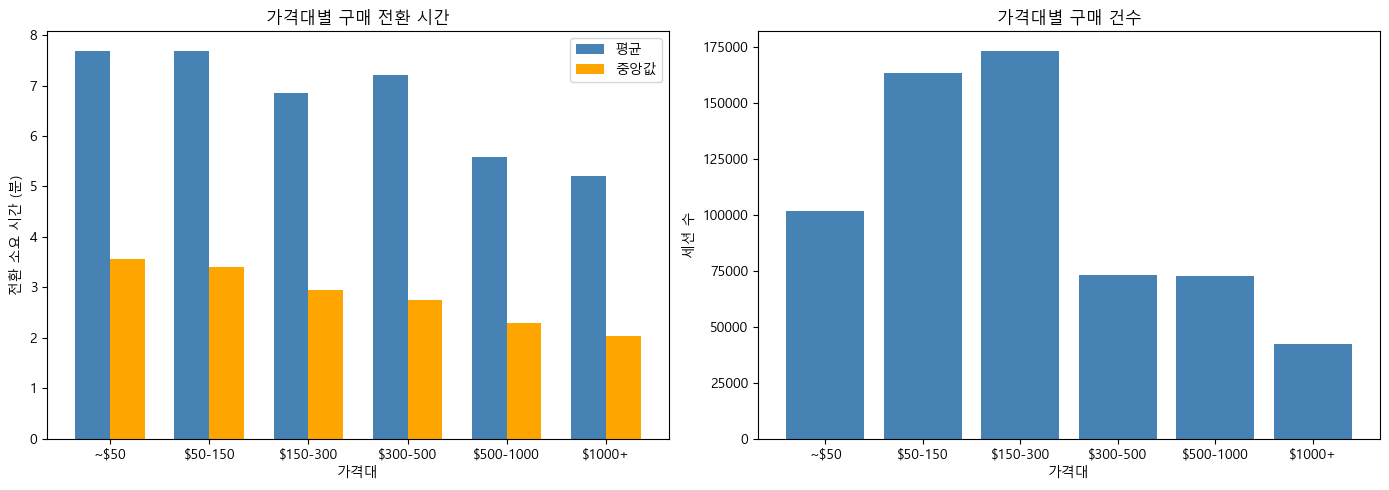

In [19]:
# 5. 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 vs 중앙값 전환 시간
x = range(len(price_conversion))
width = 0.35

axes[0].bar([i - width/2 for i in x], price_conversion['평균'], width=width, label='평균', color='steelblue')
axes[0].bar([i + width/2 for i in x], price_conversion['중앙값'], width=width, label='중앙값', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(price_conversion['price_bucket'])
axes[0].set_xlabel('가격대')
axes[0].set_ylabel('전환 소요 시간 (분)')
axes[0].set_title('가격대별 구매 전환 시간')
axes[0].legend()

# 가격대별 건수
axes[1].bar(price_conversion['price_bucket'], price_conversion['건수'], color='steelblue')
axes[1].set_xlabel('가격대')
axes[1].set_ylabel('세션 수')
axes[1].set_title('가격대별 구매 건수')

plt.tight_layout()
plt.show()

In [20]:
print(conversion['price'].describe())
print(conversion['price'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    627691.000000
mean        310.078580
std         354.409477
min           0.000000
25%          83.630000
50%         177.100000
75%         373.500000
max        2574.070000
Name: price, dtype: float64
0.25      83.63
0.50     177.10
0.75     373.50
0.90     801.82
0.95    1023.71
0.99    1671.83
Name: price, dtype: float64


In [21]:
# 1. 첫 view 시간에서 시간대 추출
conversion['hour'] = conversion['first_purchase_time'].dt.hour
conversion['time_segment'] = conversion['hour'].apply(time_segment)

# 2. 시간대별 평균/중앙값 전환 시간
segment_order = ['새벽 (0-6시)', '오전 (6-12시)', '오후 (12-18시)', '저녁 (18-24시)']
time_conversion = conversion.groupby('time_segment')['conversion_minutes'].agg(
    평균='mean',
    중앙값='median',
    건수='count'
).reindex(segment_order).reset_index()

print(time_conversion)

  time_segment        평균       중앙값      건수
0    새벽 (0-6시)  7.924899  3.383333  128353
1   오전 (6-12시)  6.159660  2.783333   29229
2  오후 (12-18시)  6.789980  2.833333  238914
3  저녁 (18-24시)  6.776294  2.916667  231195


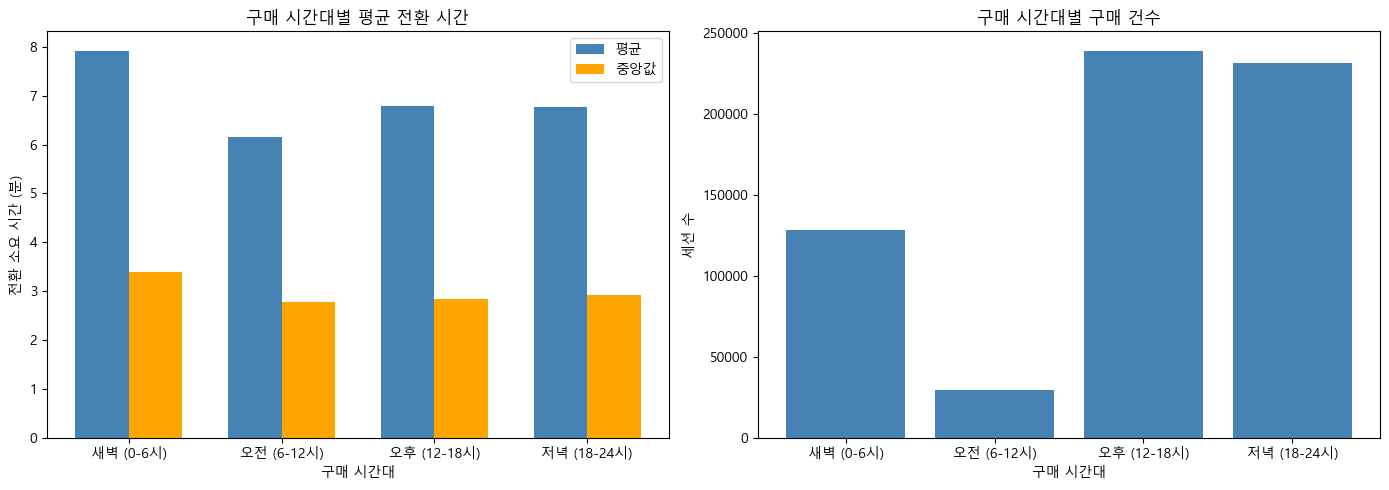

In [22]:
# 3. 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 vs 중앙값 전환 시간
x = range(len(time_conversion))
width = 0.35

axes[0].bar([i - width/2 for i in x], time_conversion['평균'], width=width, label='평균', color='steelblue')
axes[0].bar([i + width/2 for i in x], time_conversion['중앙값'], width=width, label='중앙값', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(time_conversion['time_segment'])
axes[0].set_xlabel('구매 시간대')
axes[0].set_ylabel('전환 소요 시간 (분)')
axes[0].set_title('구매 시간대별 평균 전환 시간')
axes[0].legend()

# 시간대별 구매 건수
axes[1].bar(time_conversion['time_segment'], time_conversion['건수'], color='steelblue')
axes[1].set_xlabel('구매 시간대')
axes[1].set_ylabel('세션 수')
axes[1].set_title('구매 시간대별 구매 건수')

plt.tight_layout()
plt.show()

In [23]:
# 1. 세션별 구매 브랜드 가져오기
first_purchase_brand = (
    df_filtered[df_filtered['event_type'] == 'purchase']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'brand'])
    .rename('brand')
)

# 2. conversion 테이블에 brand 합치기
conversion = conversion.drop(columns=['brand'], errors='ignore')
conversion = conversion.join(first_purchase_brand)

# 3. 브랜드별 평균/중앙값 전환 시간 (건수 50건 이상만)
brand_conversion = (
    conversion.groupby('brand')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)
brand_conversion = brand_conversion[brand_conversion['건수'] >= 50]

print(f"브랜드 수: {len(brand_conversion)}")
print(brand_conversion.sort_values('평균').head(10))  # 전환 빠른 상위 10개
print(brand_conversion.sort_values('평균').tail(10))  # 전환 느린 상위 10개

브랜드 수: 446
            brand        평균       중앙값   건수
1274     nutricia  2.641379  1.791667   58
1251     nintendo  2.836330  1.450000  178
517            ea  3.329973  1.583333  615
1347         peda  3.538672  2.491667  128
1067      m-audio  3.650769  1.850000   65
1144      merries  3.772872  2.050000   94
701         giant  3.828763  1.100000   62
1650  steelseries  3.878455  1.241667   82
188       bardahl  3.934409  1.983333   62
476          dior  3.974371  1.900000  212
         brand         평균       중앙값    건수
743    greyder  14.747079  4.733333    97
424      cybex  14.820513  5.566667    65
1694   tarkett  16.086029  3.808333    68
35      aimoto  16.231616  5.250000   262
1255     nitto  16.368667  5.016667    75
317     cantra  17.284664  3.683333   213
333      casio  21.742222  3.850000  2342
1377    playme  22.083648  6.350000    53
452   delonghi  37.008528  3.400000   342
785      hertz  63.074142  3.291667   136


In [24]:
# 1. 스마트폰 카테고리의 구매 세션만 필터링
smartphone_sessions = df_filtered[
    (df_filtered['event_type'] == 'purchase') &
    (df_filtered['category_code'] == 'electronics.smartphone')
]['user_session'].unique()

df_smartphone = df_filtered[df_filtered['user_session'].isin(smartphone_sessions)]

# 2. 세션별 구매 브랜드 가져오기
first_purchase_brand = (
    df_smartphone[df_smartphone['event_type'] == 'purchase']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'brand'])
    .rename('brand')
)

# 3. conversion 테이블에 brand 합치기
conversion_smartphone = conversion[conversion.index.isin(smartphone_sessions)].copy()
conversion_smartphone = conversion_smartphone.drop(columns=['brand'], errors='ignore')
conversion_smartphone = conversion_smartphone.join(first_purchase_brand)

# 4. 브랜드별 평균/중앙값 전환 시간 (건수 50건 이상만)
brand_conversion = (
    conversion_smartphone.groupby('brand')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)
brand_conversion = brand_conversion[brand_conversion['건수'] >= 50]

print(f"브랜드 수: {len(brand_conversion)}")
print(brand_conversion.sort_values('평균'))

브랜드 수: 25
         brand         평균       중앙값      건수
183    lucente   3.104610  1.483333     141
22       artel   4.061616  3.041667      66
15       apple   4.462759  2.016667   96453
1         acer   4.503415  2.133333     122
135         hp   5.236928  1.816667      51
276    samsung   5.385814  2.583333  118497
245  prestigio   5.510994  2.800000     238
337        zte   5.978799  3.733333     136
177     lenovo   6.188806  2.500000      67
226    oneplus   6.380664  2.316667     437
178         lg   6.446041  3.100000     261
147       inoi   6.760431  3.700000     147
227       oppo   6.845695  3.250000    9083
191      meizu   7.011028  3.516667    1401
127      haier   7.349667  4.491667     100
44          bq   7.747807  4.325000      76
289       sony   7.777679  3.350000     507
137     huawei   8.191489  3.416667   18247
216      nokia   8.268443  4.150000     469
311    tp-link   8.291694  2.750000     305
325       vivo   8.382347  2.816667    1689
332     xiaomi   9.147

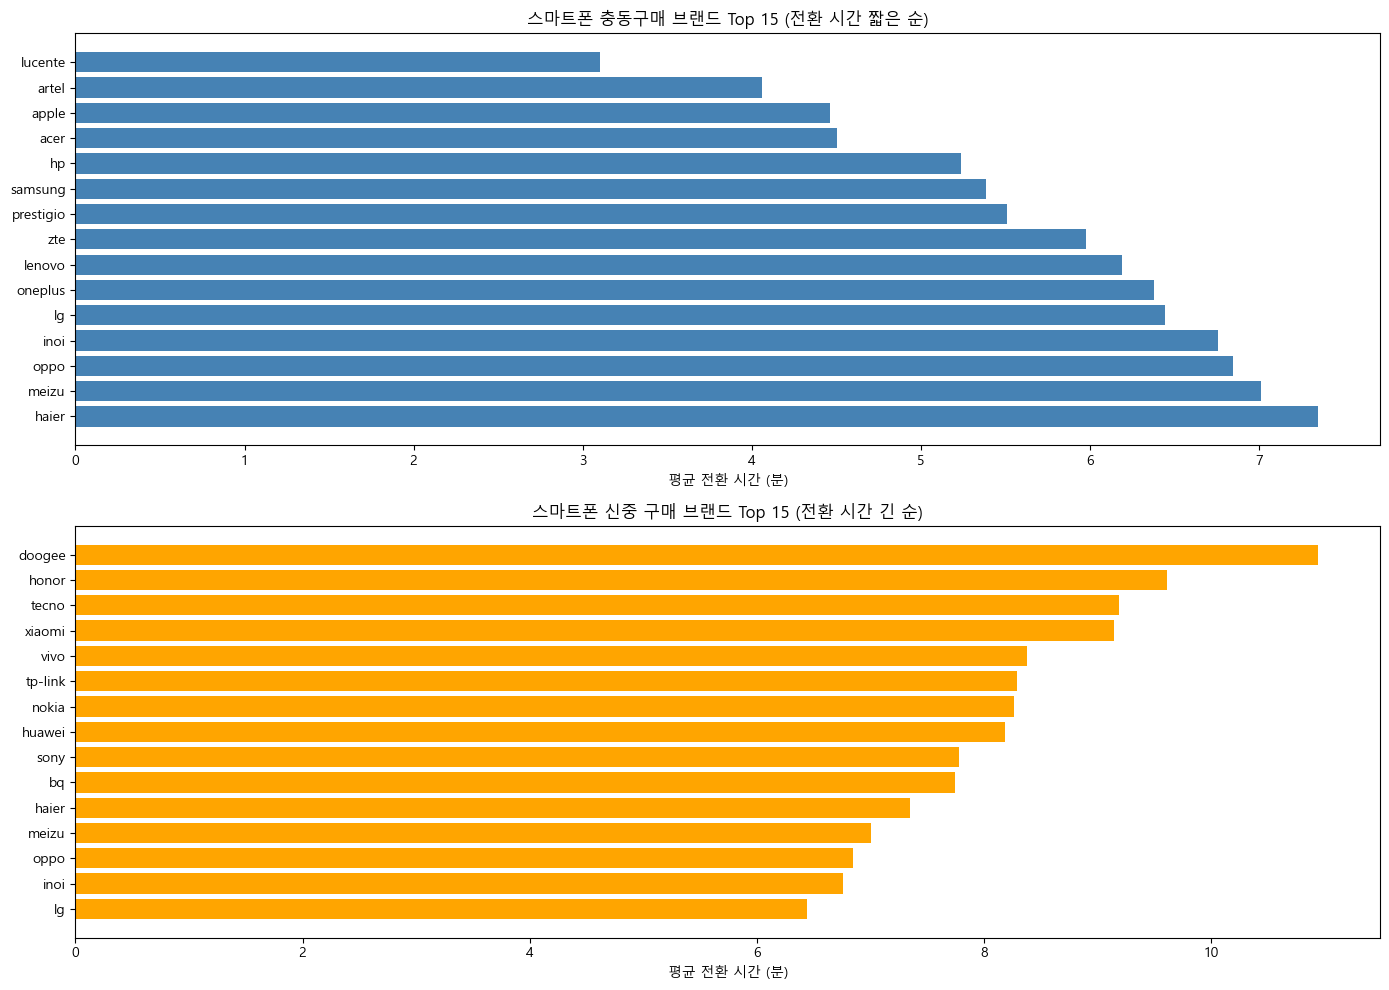

In [25]:
# 5. 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

top_fast = brand_conversion.nsmallest(15, '평균')
top_slow = brand_conversion.nlargest(15, '평균')

axes[0].barh(top_fast['brand'], top_fast['평균'], color='steelblue')
axes[0].set_xlabel('평균 전환 시간 (분)')
axes[0].set_title('스마트폰 충동구매 브랜드 Top 15 (전환 시간 짧은 순)')
axes[0].invert_yaxis()

axes[1].barh(top_slow['brand'], top_slow['평균'], color='orange')
axes[1].set_xlabel('평균 전환 시간 (분)')
axes[1].set_title('스마트폰 신중 구매 브랜드 Top 15 (전환 시간 긴 순)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [26]:
import matplotlib.pyplot as plt

# 1. 전자제품 세션 필터링
electronics_sessions = df_filtered[
    (df_filtered['event_type'] == 'purchase') &
    (df_filtered['category_code'].str.contains('electronics', na=False))
]['user_session'].unique()

df_electronics = df_filtered[df_filtered['user_session'].isin(electronics_sessions)]

# 2. 세션별 구매 브랜드 가져오기
first_purchase_brand = (
    df_electronics[df_electronics['event_type'] == 'purchase']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'brand'])
    .rename('brand')
)

# 3. conversion 테이블에 brand 합치기
conversion_electronics = conversion[conversion.index.isin(electronics_sessions)].copy()
conversion_electronics = conversion_electronics.drop(columns=['brand'], errors='ignore')
conversion_electronics = conversion_electronics.join(first_purchase_brand)

# 4. 브랜드별 집계 (건수 10건 이상만)
brand_conversion = (
    conversion_electronics.groupby('brand')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)
brand_conversion = brand_conversion[brand_conversion['건수'] >= 10].sort_values('평균')

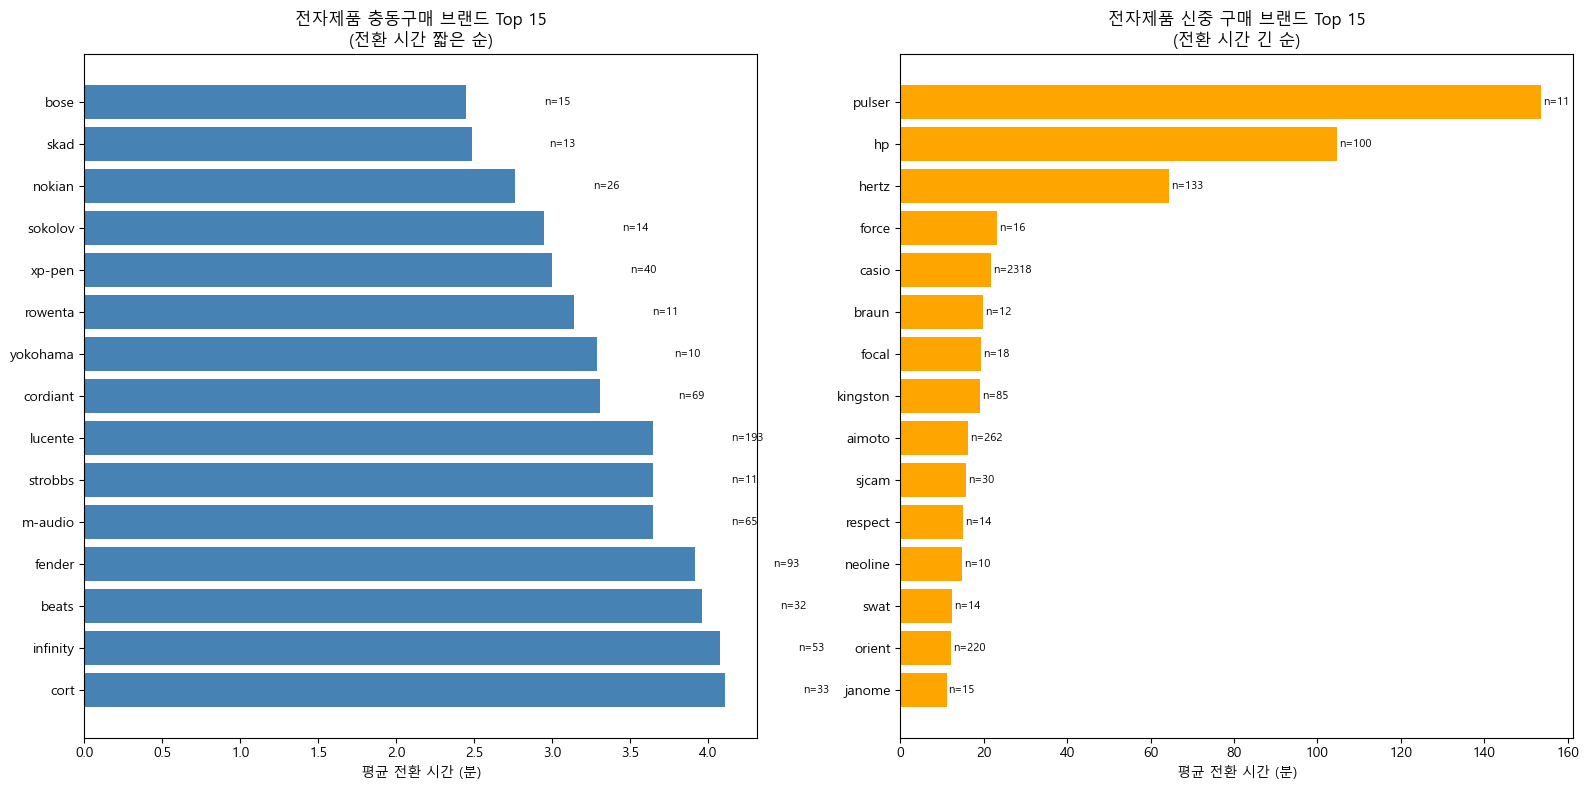

In [27]:

# 5. 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_fast = brand_conversion.nsmallest(15, '평균')
top_slow = brand_conversion.nlargest(15, '평균')

# 충동구매 브랜드
bars1 = axes[0].barh(top_fast['brand'], top_fast['평균'], color='steelblue')
axes[0].set_xlabel('평균 전환 시간 (분)')
axes[0].set_title('전자제품 충동구매 브랜드 Top 15\n(전환 시간 짧은 순)')
axes[0].invert_yaxis()
# 건수 표시
for bar, count in zip(bars1, top_fast['건수']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'n={count}', va='center', fontsize=8)

# 신중 구매 브랜드
bars2 = axes[1].barh(top_slow['brand'], top_slow['평균'], color='orange')
axes[1].set_xlabel('평균 전환 시간 (분)')
axes[1].set_title('전자제품 신중 구매 브랜드 Top 15\n(전환 시간 긴 순)')
axes[1].invert_yaxis()
# 건수 표시
for bar, count in zip(bars2, top_slow['건수']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'n={count}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
# 1. 세션별 view 횟수 집계
view_counts = (
    df_filtered[df_filtered['event_type'] == 'view']
    .groupby('user_session')
    .size()
    .rename('view_count')
)

# 2. conversion 테이블에 view 횟수 합치기
conversion = conversion.drop(columns=['view_count'], errors='ignore')
conversion = conversion.join(view_counts)

print(conversion['view_count'].describe())

count    627691.000000
mean          5.573899
std           7.821051
min           1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         384.000000
Name: view_count, dtype: float64


In [29]:
bins = [0, 1, 2, 3, 5, 10, float('inf')]
labels = ['1회', '2회', '3회', '4-5회', '6-10회', '11회+']

conversion['view_bucket'] = pd.cut(conversion['view_count'], bins=bins, labels=labels)

view_conversion = (
    conversion.groupby('view_bucket')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)

print(view_conversion)

  view_bucket         평균        중앙값      건수
0          1회   2.462604   1.716667  107011
1          2회   3.028760   1.783333  144545
2          3회   4.156699   2.450000   92343
3        4-5회   6.151714   3.466667  105126
4       6-10회   9.358051   5.700000  101514
5        11회+  22.089558  13.016667   77152


In [30]:
bins = [0, 3, 6, 10, 20, float('inf')]
labels = ['1-3회', '4-6회', '7-10회', '11-20회', '21회+']

conversion['view_bucket'] = pd.cut(conversion['view_count'], bins=bins, labels=labels)

view_conversion = (
    conversion.groupby('view_bucket')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)

print(view_conversion)

  view_bucket         평균        중앙값      건수
0        1-3회   3.155461   1.916667  343899
1        4-6회   6.509089   3.700000  136922
2       7-10회  10.118489   6.266667   69718
3      11-20회  16.384154  10.633333   52547
4        21회+  34.274148  21.616667   24605


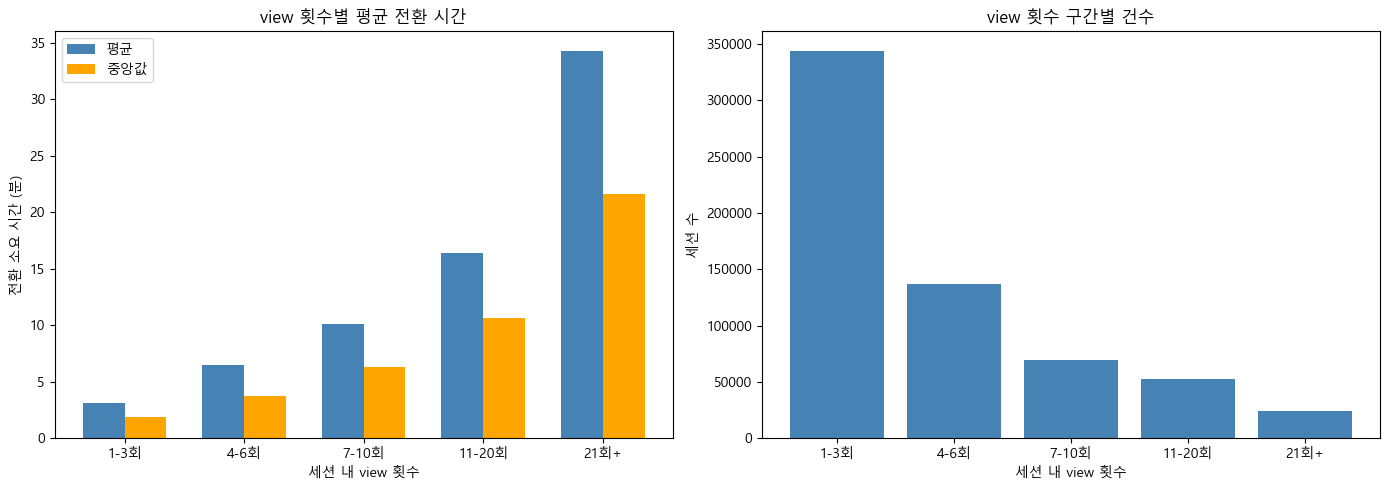

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(view_conversion))
width = 0.35

axes[0].bar([i - width/2 for i in x], view_conversion['평균'], width=width, label='평균', color='steelblue')
axes[0].bar([i + width/2 for i in x], view_conversion['중앙값'], width=width, label='중앙값', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(view_conversion['view_bucket'])
axes[0].set_xlabel('세션 내 view 횟수')
axes[0].set_ylabel('전환 소요 시간 (분)')
axes[0].set_title('view 횟수별 평균 전환 시간')
axes[0].legend()

axes[1].bar(view_conversion['view_bucket'], view_conversion['건수'], color='steelblue')
axes[1].set_xlabel('세션 내 view 횟수')
axes[1].set_ylabel('세션 수')
axes[1].set_title('view 횟수 구간별 건수')

plt.tight_layout()
plt.show()